# **Heavy Equipment Selling Price Prediction**

This is a Supervised Machine Learning Problem due to the fact that labeled data is given and the Target value is also given to make prediction upon. This is a Regression Problem beacuse we have to predict a continuos numerial value. The evaluation metric used for this will be RSMLE.

# 1. Import Libraries & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', parse_dates=['TransactionDate'])
test_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv', parse_dates=['TransactionDate'])

# 2. EDA

In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (138701, 50)
Test shape: (15000, 49)


In [4]:
train_df.head() # prints first 5 rows

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [5]:
# the missing column in test is the target
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   TransactionID              138701 non-null  int64         
 1   TargetValue                138701 non-null  float64       
 2   AssetID                    138701 non-null  int64         
 3   ProductConfigID            138701 non-null  int64         
 4   DataOriginCode             138701 non-null  object        
 5   VendorPartnerID            138701 non-null  object        
 6   ManufactureYear            138701 non-null  int64         
 7   OperationalHoursMeter      82058 non-null   float64       
 8   UtilizationTier            50475 non-null   object        
 9   TransactionDate            138701 non-null  datetime64[ns]
 10  Spec_FullDescriptor        138701 non-null  object        
 11  Spec_BaseClass             138701 non-null  object  

In [6]:
# gives description of the colums
train_df.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter,TransactionDate
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04,138701
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03,2007-12-20 17:36:50.415209728
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00,1990-01-31 00:00:00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00,2005-11-18 00:00:00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03,2009-08-20 00:00:00
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03,2011-05-12 00:00:00
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06,2013-04-28 00:00:00
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04,NaN


## Duplicates Handeling

In [7]:
print("Train Duplicates:", train_df.duplicated().sum())
print("Test Duplicates:", test_df.duplicated().sum())
# .duplicated().sum() prints out the sum of all the duplicates in the dataframe from all the rows and columns.

Train Duplicates: 0
Test Duplicates: 0


**Note:** No Duplicates found

Target skew: 0.97


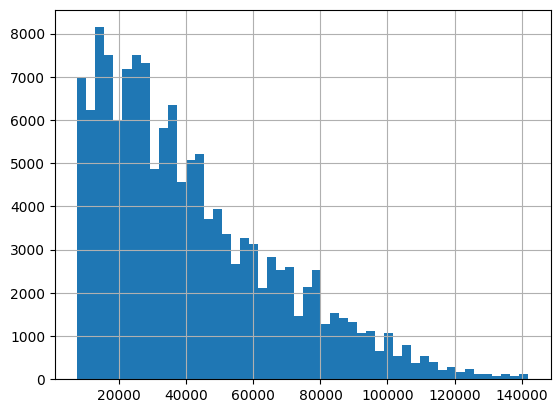

In [8]:
train_df['TargetValue'].hist(bins=50)
print("Target skew:", round(train_df['TargetValue'].skew(), 2)) # rounding the value to 2 decimal places

**Note:** Right-skewed 0.97, so training on log1p(target) — RMSLE metric

I measured skewness because if the data is skewed then it can pull the mean based on extreme values, which will result in inaccurate predictions for most of the data.

## Null Values

In [9]:
print("Train Nulls:", train_df.isnull().sum())
print("Test Nulls:", test_df.isnull().sum())
# prints out all the sum of all the null values in the column.
# used .sum() to print the sum value rather than a True/False for null values in rows.

Train Nulls: TransactionID                     0
TargetValue                       0
AssetID                           0
ProductConfigID                   0
DataOriginCode                    0
VendorPartnerID                   0
ManufactureYear                   0
OperationalHoursMeter         56643
UtilizationTier               88226
TransactionDate                   0
Spec_FullDescriptor               0
Spec_BaseClass                    0
Spec_SubClass                 36985
Spec_ReleaseSeries           105805
Spec_VariantModifier          86369
AssetScaleFactor              41210
FunctionalClassification          0
RegionCode                        0
InventoryGroupCategory            0
InventoryGroupDescription         0
col1                         104915
CabinType                         0
Forks                        109382
col3                         109448
col4                         128320
DrivetrainType                89956
col5                         128320
col6           

**Note:** Since the count of null values is high, i did not delete the rows using df.dropna() because it will remove all the rows

In [10]:
missing = train_df.isnull().sum() / len(train_df) * 100 # calculates the percentage of null values in each column
print("Columns >90% missing:", (missing > 90).sum())

Columns >90% missing: 4


**Note:** LightGBM handles NaN so no need to remove them, and missing values itself can be a signal

## Univariate Analysis

<Axes: >

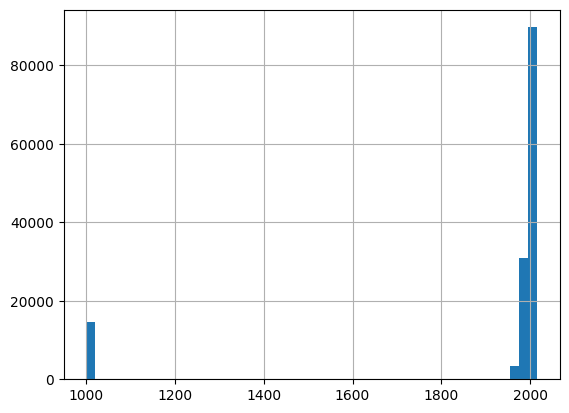

In [11]:
train_df['ManufactureYear'].hist(bins=50)

**Note:** Years near 1000 are not real years, they are an anomaly

Replace years before 1900 with NaN.

<Axes: ylabel='RegionCode'>

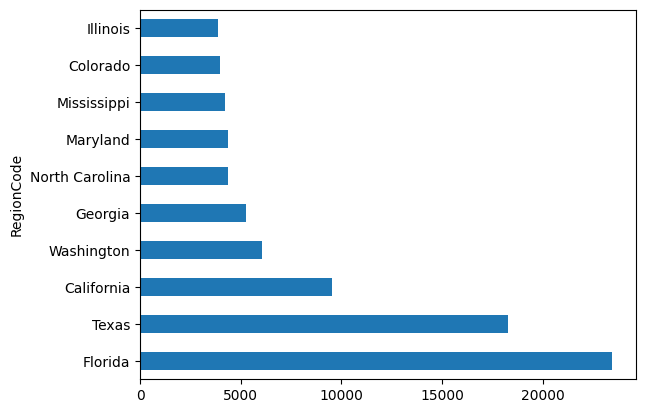

In [12]:
train_df['RegionCode'].value_counts().head(10).plot(kind='barh') # to check the volumes of top 10 regions 

**Note:** Florida, Texas, California are the highest volume regions

In [13]:
print("Hours missing %:", round(train_df['OperationalHoursMeter'].isnull().mean() * 100, 1))
print("Hours zeros:", (train_df['OperationalHoursMeter'] == 0).sum())

Hours missing %: 40.8
Hours zeros: 31583


 **Note:** 40.8% missing and 31,583 fake zeros.
 
 Replace 0 with NaN.

In [14]:
cnt = train_df.groupby('AssetID').size()
print("Assets sold more than once:", (cnt > 1).sum())

Assets sold more than once: 12857


## Bivariate Analysis

<Axes: xlabel='AssetAge'>

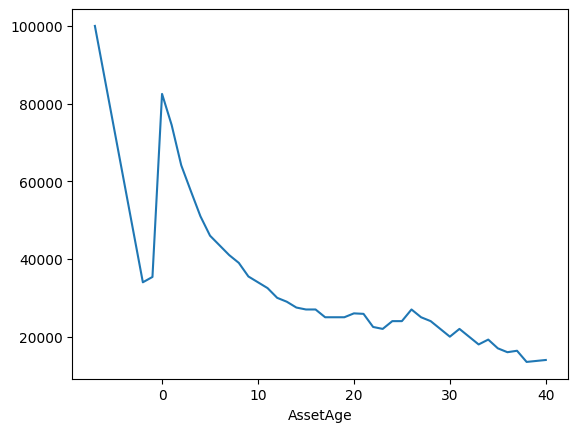

In [15]:
x = train_df.copy()
x['MY'] = x['ManufactureYear'].where(x['ManufactureYear'] >= 1930, np.nan)
x['AssetAge'] = x['TransactionDate'].dt.year - x['MY']
x.groupby('AssetAge')['TargetValue'].median().loc[:40].plot(kind='line')

**Note:** Older machines sell for less.

AssetAge is a strong predictor

<Axes: >

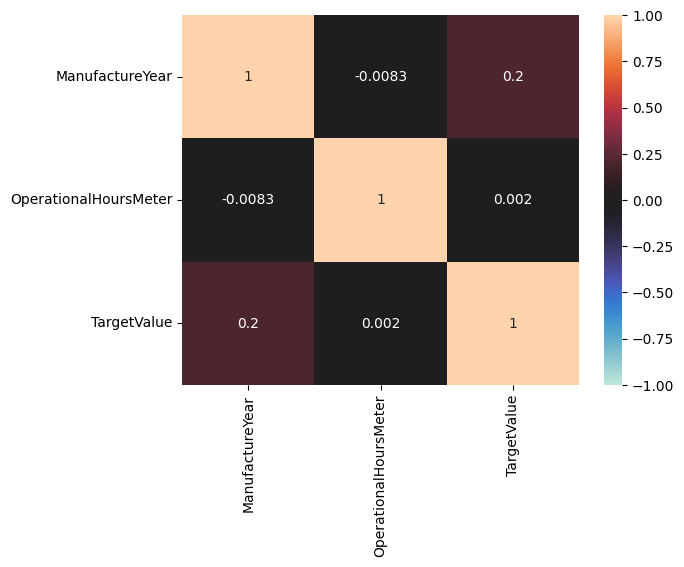

In [16]:
nums_column = ['ManufactureYear', 'OperationalHoursMeter', 'TargetValue']
mat = train_df[nums_column].corr()
sns.heatmap(mat, annot=True, center=0, vmin=-1, vmax=+1)

ManufatureYear and OperationalHoursMeter show almost no coorelation with each other (-0.008)

ManufactureYear and TargetValue show a weak positive oorelation with each other (0.2)

OperationalHoursMeter and TargetValue show near 0 coorelation with eah other (0.002)

# 3. Preprocessing & Feature Engineering

In [17]:
NONE = {'none or unspecified', 'none', 'unspecified', 'nan', 'na', ''}

def engineer_features(df): # reating a function makes it easy to apply these to both train and test
    df = df.copy()

    df['ManufactureYear'] = df['ManufactureYear'].where(df['ManufactureYear'] >= 1900, np.nan) # removes the anomaly found in eda

    df['TransactionYear']  = df['TransactionDate'].dt.year
    df['TransactionMonth'] = df['TransactionDate'].dt.month 

    df['AssetAge'] = df['TransactionYear'] - df['ManufactureYear'] # gets the age of the asset/machine
    df.loc[df['AssetAge'] < 0, 'AssetAge'] = np.nan # replaing negative values with nan    

    df['OperationalHoursMeter'] = df['OperationalHoursMeter'].replace(0, np.nan) 
    df['Hours_Per_Year'] = df['OperationalHoursMeter'] / df['AssetAge'].replace(0, np.nan) # assigning nan to avoid getting divided by 0 for new machines
    df['HasHours'] = df['OperationalHoursMeter'].notna().astype(int)

    for c in df.columns:
        if str(df[c].dtype) == 'object':
            mask = df[c].astype(str).str.strip().str.lower().isin(NONE)
            df[c] = df[c].where(~mask, np.nan)

    df['Blank_Column_Count'] = df.isnull().sum(axis=1) # gives empty columns for each row
    df['DescriptorLength']   = df['Spec_FullDescriptor'].astype(str).str.len() # gives length of desription
    return df

In [18]:
train_df = engineer_features(train_df)
test_df  = engineer_features(test_df)
print("Feature Engineering done:", train_df.shape, test_df.shape)

Feature Engineering done: (138701, 57) (15000, 56)


# 4. Encoding

## Label Encoding

In [19]:
y = np.log1p(train_df['TargetValue']) # log-transform the skewed target tp match the training to the RMSLE metric, only done on train data 

full = pd.concat([train_df.drop(columns=['TargetValue']), test_df], ignore_index=True) # target value is dropped to prevent leakage, concat is done so that the same codes are applied to both the train and test data

string_cols = [c for c in full.columns if str(full[c].dtype) == 'object']
category_cols = string_cols + ['ProductConfigID']  # productid added seperately because it contains numbers but actualy works as category
# label enoding categorials to codes
for c in category_cols:
    full[c] = pd.Categorical(full[c].astype(str)).codes  

DROP = ['TransactionID', 'TransactionDate'] # transaction id is of no use and already changed the date to yesr/month
# the previously done concat is seperated 
X      = full.iloc[:len(train_df)].drop(columns=DROP).reset_index(drop=True) # drops above columns and resets the index to maintain consistency
X_test = full.iloc[len(train_df):].drop(columns=DROP).reset_index(drop=True)
CAT_FEATURES = [c for c in category_cols if c in X.columns]

print(X.shape, len(CAT_FEATURES), 'categorical features')

(138701, 54) 44 categorical features


## Train Test Split

**Note:** The split is done after feature engineering and label enoding because the feature engineering that was done does not touch the target or performs any computation so there is no chance of leakage, same in label encoding 

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=pd.qcut(y, q=5, labels=False)) # q=5 makes 5 eqaul buckets to maintain same price distribution in train/test

# 5. Scaling & Pipeline

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [22]:
X_train_clean = X_train.replace([np.inf, -np.inf], np.nan)
X_val_clean   = X_val.replace([np.inf, -np.inf], np.nan)

In [23]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-999)),
    ('scaler', StandardScaler())
])

In [24]:
X_train_scl = pipeline.fit_transform(X_train_clean) # learns mean/std from train
X_val_scl   = pipeline.transform(X_val_clean) # applies mean/std of train

# 6. Model Building

In [25]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

In [26]:
dict_scores = {}

## 6.1 Ridge

In [27]:
ridge_regressor = Ridge(alpha=1.0)
ridge_regressor.fit(X_train_scl, y_train)
val_predictions_ridge = ridge_regressor.predict(X_val_scl)
dict_scores['1. Ridge'] = np.sqrt(mean_squared_error(y_val, val_predictions_ridge))
print(dict_scores)

{'1. Ridge': np.float64(0.48052751722167886)}


## 6.2 Random Forest

In [28]:
rf_grid = {'n_estimators': [50, 100], 'max_depth': [10, 15]}
rf_tuner = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                              param_distributions=rf_grid, n_iter=4, cv=4,
                              random_state=42)
rf_tuner.fit(X_train_clean, y_train)
val_predictions_rf = rf_tuner.predict(X_val_clean)
dict_scores['2. Random Forest(Tuned)'] = np.sqrt(mean_squared_error(y_val, val_predictions_rf))
print(dict_scores)

{'1. Ridge': np.float64(0.48052751722167886), '2. Random Forest(Tuned)': np.float64(0.23834471460526696)}


## 6.3 LightGBM

In [29]:
lgbm = lgb.LGBMRegressor(learning_rate=0.001, num_leaves=400, subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
                               reg_lambda=1.0, reg_alpha=0.5, random_state=42, n_estimators=35000) 

lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                     categorical_feature=CAT_FEATURES,
                     callbacks=[lgb.early_stopping(200)]) 

val_predictions_lgb = lgbm.predict(X_val, num_iteration=lgbm.best_iteration_)

dict_scores['3. LightGBM'] = np.sqrt(mean_squared_error(y_val, val_predictions_lgb))
print('best_iteration:', lgbm.best_iteration_)
print(dict_scores)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6591
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 53
[LightGBM] [Info] Start training from score 10.424287
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[30710]	valid_0's l2: 0.0403644
best_iteration: 30710
{'1. Ridge': np.float64(0.48052751722167886), '2. Random Forest(Tuned)': np.float64(0.23834471460526696), '3. LightGBM': np.float64(0.2009088736093211)}


<Axes: >

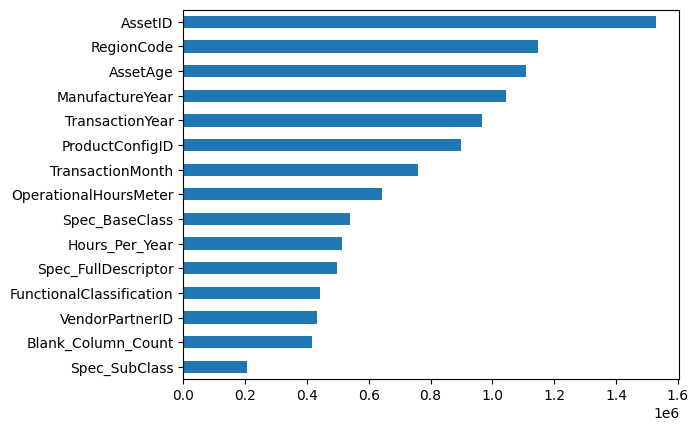

In [30]:
imp = pd.Series(lgbm.feature_importances_, index=X_train.columns)
imp.sort_values().tail(15).plot(kind='barh')

# 7. Model Comparrision

{'1. Ridge': np.float64(0.48052751722167886), '2. Random Forest(Tuned)': np.float64(0.23834471460526696), '3. LightGBM': np.float64(0.2009088736093211)}


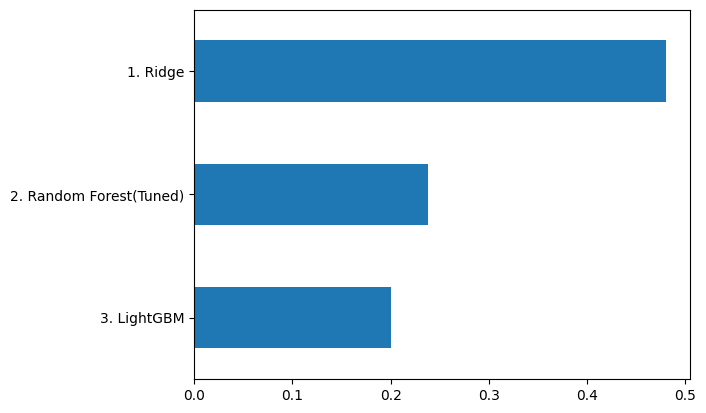

In [31]:
pd.Series(dict_scores).sort_values().plot(kind='barh')
print(dict_scores)

LightGBM beats Ridge and Random Forest.

# 8. Submission

In [32]:
test_log = lgbm.predict(X_test, num_iteration=lgbm.best_iteration_)
predicted_real_prices = np.clip(np.expm1(test_log),
                                train_df['TargetValue'].min(), train_df['TargetValue'].max())
submission = pd.DataFrame({'TransactionID': test_df['TransactionID'],
                           'TargetValue': predicted_real_prices})
submission.to_csv('submission.csv', index=False)